# Youtube Analysis for Hantavirus

## Introduction

## How to Run the Notebook

## 1. YouTube API Client
This function creates a connection to the YouTube Data API using an API key, allowing the program to retrieve video and comment data.

The data is collected using the YouTube Data API v3.  
A set of highly relevant videos was selected using keyword-based search.  
Comments were collected from these videos for later sentiment and text analysis.

In [1]:
!pip install google-api-python-client

In [ ]:
# from example given youtubeClient.py
# @author Hexu Chen, RMIT University, 2026
# @author Chenglong Ma, RMIT University, 2026

from googleapiclient.discovery import build

def youtubeClient():
    apiKey = "apikey" # this was my api key
    youtube = build('youtube', 'v3', developerKey=apiKey)
    return youtube

## 2. Fetching Youtube Data
This section collects Hantavirus-related YouTube videos and comments using the YouTube Data API. Multiple search queries are used to capture news, public health, expert explanation and general outbreak discussion videos.

This section does not need to be re-run once the data has been saved. The collected dataset is saved as:

`Data/hantavirus_youtube_data.json`

In [3]:
import json
import os

In [4]:
SEARCH_QUERIES = [
    "hantavirus outbreak news",
    "hantavirus cruise ship outbreak",
    "hantavirus cruise ship news",
    "hantavirus update",
    "hantavirus risk explained",
    "hantavirus symptoms transmission",
    "hantavirus expert explains",
    "hantavirus public health",
    "hantavirus 2026"
]

MAX_VIDEOS_PER_QUERY = 12
MAX_COMMENTS_PER_VIDEO = None
OUTPUT_FILE = "Data/hantavirus_youtube_data.json"

In [5]:
def fetchYoutubeDataMultipleQueries(
    searchQueries,
    maxVideosPerQuery=12,
    maxCommentsPerVideo=None,
    outputFile="Data/hantavirus_youtube_data.json"
):
    """
    Fetch YouTube videos and comments for multiple search queries.

    The function:
    - searches videos for each query
    - removes duplicate videos across search queries using videoId
    - fetches video statistics
    - fetches all available top-level comments if maxCommentsPerVideo is None
    - saves the final dataset to a JSON file
    """

    client = youtubeClient()

    os.makedirs(os.path.dirname(outputFile), exist_ok=True)

    videoIds = []
    videoSnippets = {}
    videoSearchQueries = {}

    # Step 1: Search for videos across multiple queries
    for query in searchQueries:
        print(f"Searching for videos with query: '{query}'...")

        searchResponse = client.search().list(
            q=query,
            part="snippet",
            type="video",
            order="relevance",
            maxResults=min(maxVideosPerQuery, 50)
        ).execute()

        for item in searchResponse.get("items", []):
            videoId = item["id"]["videoId"]

            # Avoid duplicate videos across search queries
            if videoId not in videoSnippets:
                videoIds.append(videoId)
                videoSnippets[videoId] = item["snippet"]
                videoSearchQueries[videoId] = query

    print(f"\nTotal unique videos found: {len(videoIds)}")

    if len(videoIds) == 0:
        print("No videos found. Check API setup or search queries.")
        return

    # Step 2: Fetch video statistics
    print("\nFetching video statistics...")

    videoStats = {}

    # videos.list can handle up to 50 video IDs per request
    for i in range(0, len(videoIds), 50):
        batchIds = videoIds[i:i + 50]

        statsResponse = client.videos().list(
            id=",".join(batchIds),
            part="statistics"
        ).execute()

        for item in statsResponse.get("items", []):
            videoStats[item["id"]] = item.get("statistics", {})

    # Step 3: Fetch comments
    print("\nFetching comments...")

    videos = []

    for videoId in videoIds:
        snippet = videoSnippets[videoId]
        stats = videoStats.get(videoId, {})

        video = {
            "videoId": videoId,
            "title": snippet.get("title", ""),
            "description": snippet.get("description", ""),
            "channelTitle": snippet.get("channelTitle", ""),
            "channelId": snippet.get("channelId", ""),
            "publishedAt": snippet.get("publishedAt", ""),
            "searchQuery": videoSearchQueries.get(videoId, ""),
            "url": f"https://www.youtube.com/watch?v={videoId}",
            "viewCount": int(stats.get("viewCount", 0)),
            "likeCount": int(stats.get("likeCount", 0)),
            "commentCount": int(stats.get("commentCount", 0)),
            "comments": []
        }

        try:
            commentsFetched = 0
            nextPageToken = None

            while True:
                # If maxCommentsPerVideo is None, fetch all comments page by page
                if maxCommentsPerVideo is not None:
                    requestLimit = min(100, maxCommentsPerVideo - commentsFetched)

                    if requestLimit <= 0:
                        break
                else:
                    requestLimit = 100

                commentResponse = client.commentThreads().list(
                    videoId=videoId,
                    part="snippet",
                    maxResults=requestLimit,
                    pageToken=nextPageToken,
                    textFormat="plainText",
                    order="relevance"
                ).execute()

                for commentThread in commentResponse.get("items", []):
                    topComment = commentThread["snippet"]["topLevelComment"]["snippet"]

                    video["comments"].append({
                        "commentId": commentThread.get("id", ""),
                        "author": topComment.get("authorDisplayName", ""),
                        "text": topComment.get("textDisplay", ""),
                        "publishedAt": topComment.get("publishedAt", ""),
                        "likeCount": topComment.get("likeCount", 0)
                    })

                    commentsFetched += 1

                    if maxCommentsPerVideo is not None and commentsFetched >= maxCommentsPerVideo:
                        break

                if maxCommentsPerVideo is not None and commentsFetched >= maxCommentsPerVideo:
                    break

                nextPageToken = commentResponse.get("nextPageToken")

                if not nextPageToken:
                    break

            print(f"{video['title'][:70]}... -> {len(video['comments'])} comments")

        except Exception as e:
            print(f"{video['title'][:70]}... -> Comments disabled or error: {e}")

        videos.append(video)

    # Step 4: Save to JSON
    data = {
        "searchQueries": searchQueries,
        "maxVideosPerQuery": maxVideosPerQuery,
        "maxCommentsPerVideo": maxCommentsPerVideo,
        "videos": videos
    }

    with open(outputFile, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"\nDone. Saved {len(videos)} unique videos to '{outputFile}'.")

In [6]:
fetchYoutubeDataMultipleQueries(
    SEARCH_QUERIES,
    maxVideosPerQuery=MAX_VIDEOS_PER_QUERY,
    maxCommentsPerVideo=MAX_COMMENTS_PER_VIDEO,
    outputFile=OUTPUT_FILE
)

Searching for videos with query: 'hantavirus outbreak news'...
Searching for videos with query: 'hantavirus cruise ship outbreak'...
Searching for videos with query: 'hantavirus cruise ship news'...
Searching for videos with query: 'hantavirus update'...
Searching for videos with query: 'hantavirus risk explained'...
Searching for videos with query: 'hantavirus symptoms transmission'...
Searching for videos with query: 'hantavirus expert explains'...
Searching for videos with query: 'hantavirus public health'...
Searching for videos with query: 'hantavirus 2026'...

Total unique videos found: 86

Fetching video statistics...

Fetching comments...
Hantavirus cruise ship docks after seven weeks at sea... -> 2 comments
Hantavirus outbreak sparks global health concerns and panic-driven spe... -> 17 comments
Cruise ship linked to deadly hantavirus outbreak to reach Netherlands ... -> 5 comments
Hantavirus Outbreak | Learn English with the News... -> 25 comments
Last people aboard hantavirus

## Install Required Packages (if needed)
If runnning the notebook for the firstime, install the required libraries using:

In [7]:
!pip install pandas matplotlib nltk numpy scikit-learn langid wordcloud

## 3. Load Dataset and Initial Exploration

This section loads the saved YouTube dataset collected using the YouTube Data API. The raw JSON file contains video metadata and top-level comments for Hantavirus-related videos.

The data is converted into two DataFrames:

- `videos_df`: stores video-level information such as title, channel, upload date, views, likes and number of comments fetched.
- `comments_df`: stores comment-level information such as comment text, author, video ID, channel and publication date.

This makes the dataset easier to inspect, clean and analyse in later sections.

In [ ]:
# load saved youtube dataset
file_path = "Data/hantavirus_youtube_data.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

all_videos = data["videos"]

print("Total videos:", len(all_videos))
print("Search queries used:", len(data["searchQueries"]))

Total videos: 86
Search queries used: 9


In [25]:
# convert json structure into video and comment dataframes
video_rows = []
comment_rows = []

for video in all_videos:
    video_rows.append({
        "videoId": video["videoId"],
        "title": video["title"],
        "description": video["description"],
        "channelTitle": video["channelTitle"],
        "channelId": video["channelId"],
        "publishedAt": video["publishedAt"],
        "searchQuery": video["searchQuery"],
        "url": video["url"],
        "viewCount": video["viewCount"],
        "likeCount": video["likeCount"],
        "commentCount": video["commentCount"],
        "commentsFetched": len(video["comments"])
    })

    for comment in video["comments"]:
        comment_rows.append({
            "commentId": comment["commentId"],
            "videoId": video["videoId"],
            "title": video["title"],
            "channelTitle": video["channelTitle"],
            "searchQuery": video["searchQuery"],
            "commentAuthor": comment["author"],
            "commentText": comment["text"],
            "commentPublishedAt": comment["publishedAt"],
            "commentLikeCount": comment["likeCount"]
        })

videos_df = pd.DataFrame(video_rows)
comments_df = pd.DataFrame(comment_rows)

print("Videos dataframe:", videos_df.shape)
print("Comments dataframe:", comments_df.shape)

videos_df.head()

Videos dataframe: (86, 12)
Comments dataframe: (12042, 9)


,videoId,title,description,channelTitle,channelId,publishedAt,searchQuery,url,viewCount,likeCount,commentCount,commentsFetched
0,V07bI_iyMVA,Hantavirus cruise ship docks after seven weeks...,For more context and news coverage of the most...,NBC News,UCeY0bbntWzzVIaj2z3QigXg,2026-05-18T12:58:33Z,hantavirus outbreak news,https://www.youtube.com/watch?v=V07bI_iyMVA,1558,28,3,2
1,KpZN0OA0GNc,Hantavirus outbreak sparks global health conce...,The Hantavirus outbreak linked to the MV Hondi...,SABC News,UC8yH-uI81UUtEMDsowQyx1g,2026-05-17T16:21:21Z,hantavirus outbreak news,https://www.youtube.com/watch?v=KpZN0OA0GNc,8521,0,25,17
2,4URktweTzV4,Cruise ship linked to deadly hantavirus outbre...,The cruise ship linked to the deadly hantaviru...,The New Indian Express,UCQtVJ-76KjPds9evTODkq-A,2026-05-18T08:08:09Z,hantavirus outbreak news,https://www.youtube.com/watch?v=4URktweTzV4,4046,24,6,5
3,COt1faxmdO0,Hantavirus Outbreak | Learn English with the News,Today you'll learn English with a news article...,JForrest English,UCLNBasuHKOILIwewAetJO6g,2026-05-18T12:00:30Z,hantavirus outbreak news,https://www.youtube.com/watch?v=COt1faxmdO0,1587,275,28,25
4,4KWbgoo60D4,Last people aboard hantavirus ship finally dis...,The MV Hondius was carrying 25 crew members an...,Sky News,UCoMdktPbSTixAyNGwb-UYkQ,2026-05-18T12:01:14Z,hantavirus outbreak news,https://www.youtube.com/watch?v=4KWbgoo60D4,1643,17,1,1


In [10]:
# convert to df
import pandas as pd

video_rows = []
comment_rows = []

for video in all_videos:
    video_rows.append({
        "videoId": video["videoId"],
        "title": video["title"],
        "description": video["description"],
        "channelTitle": video["channelTitle"],
        "channelId": video["channelId"],
        "publishedAt": video["publishedAt"],
        "searchQuery": video["searchQuery"],
        "url": video["url"],
        "viewCount": video["viewCount"],
        "likeCount": video["likeCount"],
        "commentCount": video["commentCount"],
        "commentsFetched": len(video["comments"])
    })

    for comment in video["comments"]:
        comment_rows.append({
            "commentId": comment["commentId"],
            "videoId": video["videoId"],
            "title": video["title"],
            "channelTitle": video["channelTitle"],
            "searchQuery": video["searchQuery"],
            "commentAuthor": comment["author"],
            "commentText": comment["text"],
            "commentPublishedAt": comment["publishedAt"],
            "commentLikeCount": comment["likeCount"]
        })

videos_df = pd.DataFrame(video_rows)
comments_df = pd.DataFrame(comment_rows)

print("Videos dataframe:", videos_df.shape)
print("Comments dataframe:", comments_df.shape)

videos_df.head()

Videos dataframe: (86, 12)
Comments dataframe: (12042, 9)


,videoId,title,description,channelTitle,channelId,publishedAt,searchQuery,url,viewCount,likeCount,commentCount,commentsFetched
0,V07bI_iyMVA,Hantavirus cruise ship docks after seven weeks...,For more context and news coverage of the most...,NBC News,UCeY0bbntWzzVIaj2z3QigXg,2026-05-18T12:58:33Z,hantavirus outbreak news,https://www.youtube.com/watch?v=V07bI_iyMVA,1558,28,3,2
1,KpZN0OA0GNc,Hantavirus outbreak sparks global health conce...,The Hantavirus outbreak linked to the MV Hondi...,SABC News,UC8yH-uI81UUtEMDsowQyx1g,2026-05-17T16:21:21Z,hantavirus outbreak news,https://www.youtube.com/watch?v=KpZN0OA0GNc,8521,0,25,17
2,4URktweTzV4,Cruise ship linked to deadly hantavirus outbre...,The cruise ship linked to the deadly hantaviru...,The New Indian Express,UCQtVJ-76KjPds9evTODkq-A,2026-05-18T08:08:09Z,hantavirus outbreak news,https://www.youtube.com/watch?v=4URktweTzV4,4046,24,6,5
3,COt1faxmdO0,Hantavirus Outbreak | Learn English with the News,Today you'll learn English with a news article...,JForrest English,UCLNBasuHKOILIwewAetJO6g,2026-05-18T12:00:30Z,hantavirus outbreak news,https://www.youtube.com/watch?v=COt1faxmdO0,1587,275,28,25
4,4KWbgoo60D4,Last people aboard hantavirus ship finally dis...,The MV Hondius was carrying 25 crew members an...,Sky News,UCoMdktPbSTixAyNGwb-UYkQ,2026-05-18T12:01:14Z,hantavirus outbreak news,https://www.youtube.com/watch?v=4KWbgoo60D4,1643,17,1,1


In [ ]:
# save converted datasets for later analysis
videos_df.to_csv("Data/youtube_videos.csv", index=False)
comments_df.to_csv("Data/youtube_comments.csv", index=False)

print("Saved youtube_videos.csv and youtube_comments.csv")

Saved youtube_videos.csv and youtube_comments.csv


### 3.1 Data Exploration

This section provides a basic overview of the YouTube dataset before text analysis. It checks the number of videos and comments collected, the distribution of comments per video, and the publication date range of the videos.

These checks help confirm whether the dataset is suitable for sentiment and topic analysis, and whether the comments are spread across enough videos to support comparison between different types of content.

In [27]:
# summarise number of comments fetched per video
total_comments = videos_df["commentsFetched"].sum()
min_comments = videos_df["commentsFetched"].min()
max_comments = videos_df["commentsFetched"].max()
avg_comments = videos_df["commentsFetched"].mean()

print("Total videos:", len(videos_df))
print("Total comments:", total_comments)
print("Minimum comments per video:", min_comments)
print("Maximum comments per video:", max_comments)
print("Average comments per video:", round(avg_comments, 2))

Total videos: 86
Total comments: 12042
Minimum comments per video: 0
Maximum comments per video: 1256
Average comments per video: 140.02


In [28]:
# show comment count for each video
for _, row in videos_df.iterrows():
    print(f"{row['title'][:70]}... -> {row['commentsFetched']} comments")

Hantavirus cruise ship docks after seven weeks at sea... -> 2 comments
Hantavirus outbreak sparks global health concerns and panic-driven spe... -> 17 comments
Cruise ship linked to deadly hantavirus outbreak to reach Netherlands ... -> 5 comments
Hantavirus Outbreak | Learn English with the News... -> 25 comments
Last people aboard hantavirus ship finally disembark... -> 1 comments
What are the origins of hantavirus? How the virus tied to the cruise s... -> 15 comments
Cruise ship hit by deadly hantavirus outbreak arrives in the Netherlan... -> 0 comments
🚢 🤢 Hantavirus Cruise Ship Outbreak: “Close Contact” - What It Really ... -> 70 comments
How Worried Should We Be About Hantavirus?... -> 43 comments
LIVE: Hantavirus Outbreak News: 3 Dead On Cruise Ship | WHO Chief Brie... -> 3 comments
Officials tracking at least 41 Americans after deadly hantavirus outbr... -> 143 comments
Why health officials expect hantavirus cases to continue rising... -> 336 comments
“No sign” of larger hantav

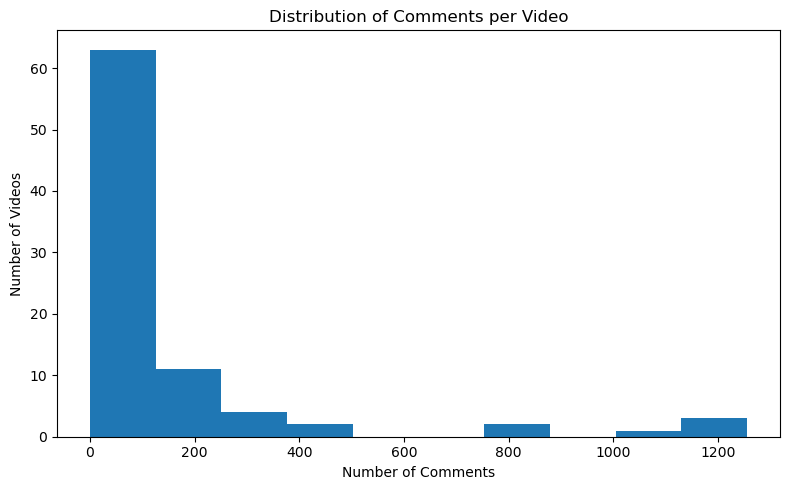

In [29]:
# histogram of comments per video
import matplotlib.pyplot as plt

# plot distribution of comments per video
plt.figure(figsize=(8, 5))
plt.hist(videos_df["commentsFetched"], bins=10)

plt.title("Distribution of Comments per Video")
plt.xlabel("Number of Comments")
plt.ylabel("Number of Videos")

plt.tight_layout()
plt.show()

In [30]:
from datetime import datetime
from collections import Counter

# convert published date to datetime
videos_df["publishedAt"] = pd.to_datetime(videos_df["publishedAt"])

# extract publication year
videos_df["year"] = videos_df["publishedAt"].dt.year

# show earliest and latest video year
print("Min year:", videos_df["year"].min())
print("Max year:", videos_df["year"].max())

# count videos per year
year_counts = videos_df["year"].value_counts().sort_index()

print("\nVideos per year:")
for year, count in year_counts.items():
    print(year, ":", count)

Min year: 2012
Max year: 2026

Videos per year:
2012 : 1
2022 : 1
2025 : 3
2026 : 81


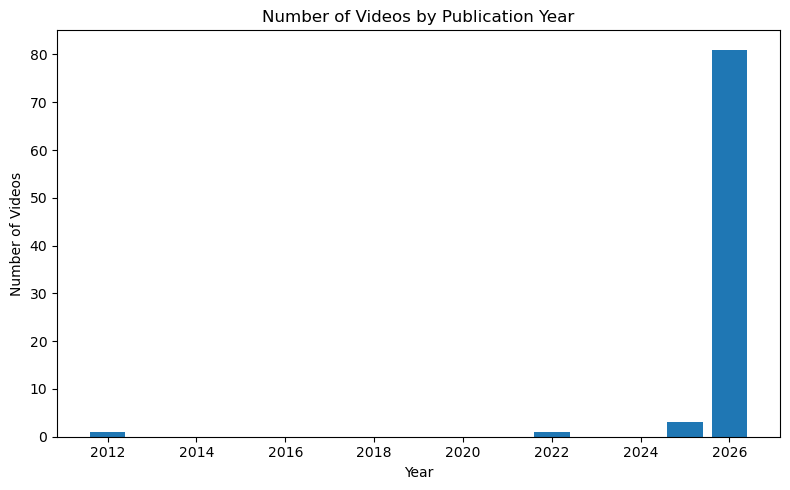

In [31]:
# plot number of videos by publication year
plt.figure(figsize=(8, 5))
plt.bar(year_counts.index, year_counts.values)

plt.title("Number of Videos by Publication Year")
plt.xlabel("Year")
plt.ylabel("Number of Videos")

plt.tight_layout()
plt.show()

/var/folders/rt/ntympq6n43582kgy0p0xxpc00000gn/T/ipykernel_54582/2910740495.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  videos_df["year_month"] = videos_df["publishedAt"].dt.to_period("M")


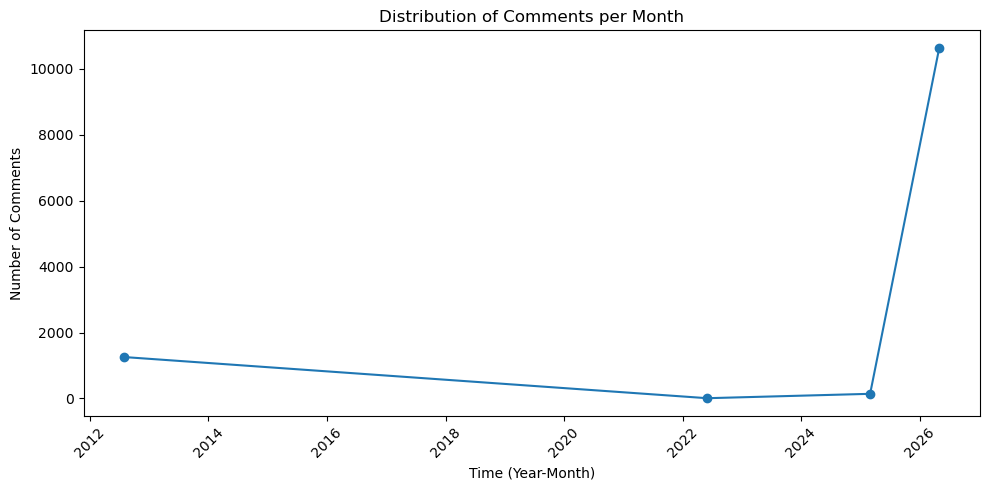

In [32]:
# create year-month column
videos_df["year_month"] = videos_df["publishedAt"].dt.to_period("M")

# aggregate fetched comments by month
comments_monthly = videos_df.groupby("year_month")["commentsFetched"].sum()

# convert period index to timestamp for plotting
comments_monthly.index = comments_monthly.index.to_timestamp()

# plot monthly comment trend
plt.figure(figsize=(10, 5))
plt.plot(comments_monthly.index, comments_monthly.values, marker="o")

plt.title("Distribution of Comments per Month")
plt.xlabel("Time (Year-Month)")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. Text Preprocessing

This section prepares the YouTube comments for text-based analysis. The preprocessing includes removing missing or empty comments, checking language, lowercasing text, tokenising comments, and removing stopwords, punctuation, digits and non-alphabetic tokens.

For VADER sentiment analysis, the notebook keeps a lightly cleaned version of each comment because VADER performs better on full sentences with context. The more heavily tokenised version is mainly used for keyword, term frequency and optional bigram analysis.

In [22]:
import string
import re
from collections import Counter

import nltk
import matplotlib.pyplot as plt
import langid

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [33]:
# remove missing and empty comments
comments_df = comments_df.dropna(subset=["commentText"]).copy()
comments_df["commentText"] = comments_df["commentText"].astype(str).str.strip()
comments_df = comments_df[comments_df["commentText"] != ""]

print("Total comments after removing empty comments:", len(comments_df))

Total comments after removing empty comments: 12042


In [42]:
# create a lightly cleaned version for vader sentiment analysis
def clean_for_sentiment(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

comments_df["cleanComment"] = comments_df["commentText"].apply(clean_for_sentiment)

comments_df[["commentText", "cleanComment"]].head()

,commentText,cleanComment
0,What happened to the CDC staff that were suppo...,What happened to the CDC staff that were suppo...
1,"Hopefully that virus, will cease from spreading.","Hopefully that virus, will cease from spreading."
2,This virus is a minor problem compared to the ...,This virus is a minor problem compared to the ...
3,I wonder what these criminals are up to now.,I wonder what these criminals are up to now.
4,When you stop reporting fake health concerns t...,When you stop reporting fake health concerns t...


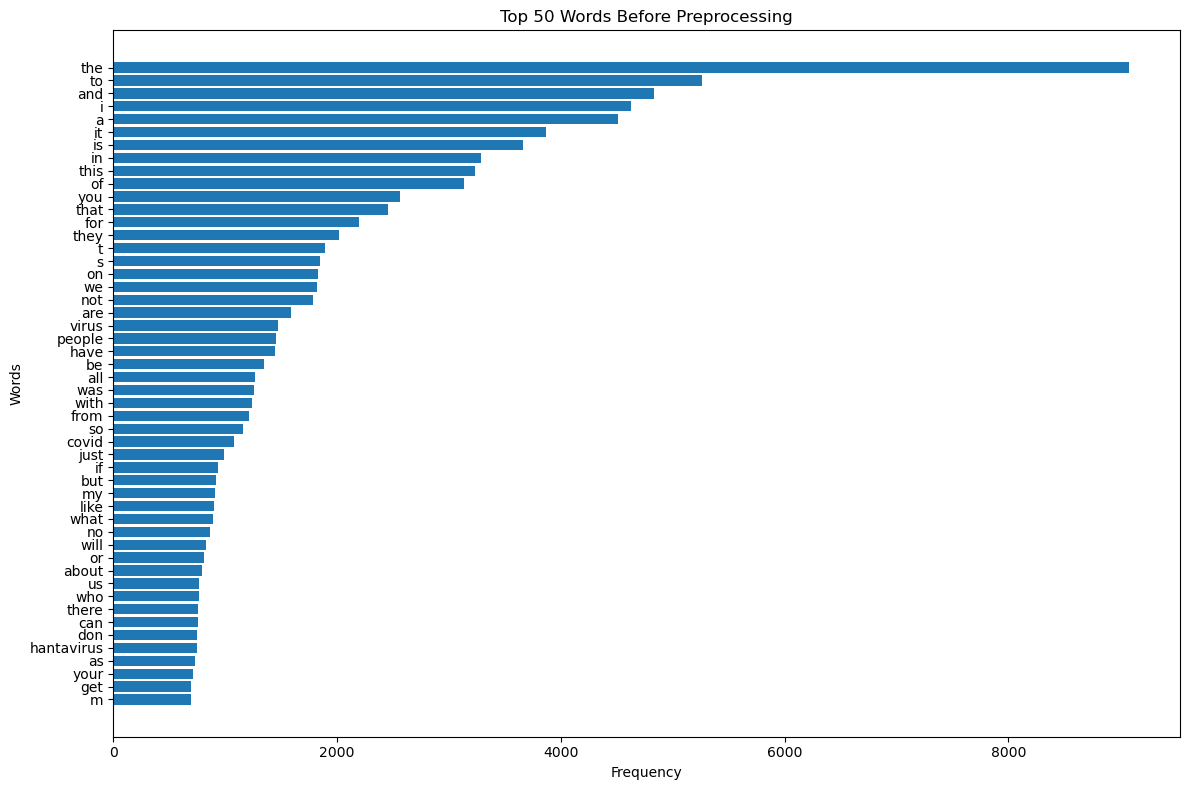

In [43]:
# check top 50 words before preprocessing
all_text = " ".join(comments_df["cleanComment"]).lower()
words = re.findall(r"\b\w+\b", all_text)

word_counts = Counter(words)
top_words = word_counts.most_common(50)

terms = [word for word, count in top_words]
values = [count for word, count in top_words]

plt.figure(figsize=(12, 8))
plt.barh(terms, values)
plt.gca().invert_yaxis()

plt.title("Top 50 Words Before Preprocessing")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

In [44]:
# check examples of comments detected as non-english
non_english_examples = []

for text in comments_df["cleanComment"]:
    
    # skip empty or very short comments
    if not text or len(text.split()) <= 4:
        continue

    lang, score = langid.classify(text)

    if lang != "en":
        non_english_examples.append((text, lang, score))

    # stop after collecting enough examples
    if len(non_english_examples) >= 20:
        break

for text, lang, score in non_english_examples:
    print(f"[{lang} | {score:.2f}] {text}")

[he | -21.37] 🚨 Global lockdowns ASAP 👆
[it | -30.74] Mamma Mia, here we go again
[vo | -56.79] Let's Go Let's Go Let's Go Mrs Jennifer ❤❤❤❤❤
[la | -49.75] Thanks a bunch, Jennifer ✅💯 Yes, Yes, Yes 👍
[ru | -2323.27] То война, то эпидемия. В следующий раз наверное будет вторжение инопланетян. Не зря же там Трамп постоянно про них упоминает.
[zh | -97.78] Sounds like ya’ll need cats😇🐈🐈‍⬛ Plenty need homes💯♥️
[es | -17.24] gUYS COME TO AUSTRALIA THEREs NO HANTA VIRUS THERe
[pl | -67.38] Gnna get ready fir zombie apocalypse
[km | -175.58] 𝑰 𝒅𝒐𝒏'𝒕 𝒘𝒂𝒏𝒕 𝒐𝒏𝒍𝒊𝒏𝒆 𝒄𝒍𝒂𝒔𝒔𝒆𝒔 😭😭😭😭
[la | -2640.61] Трумп путлер Иран натаньяку си взп орбановцы,Attention, this time is many times worse than during World War II. We stand for good. Supposedly Schmodners — Lenin, Stalin, Putin’s Epsteins, Russians–Muscovites, Trumpists, UEFA, IOC, Mask-like figures, Witkoffs, trash elites, China, MAGA, the Budapest Memorandum, CSTO, UAE, BRICS, SCO, North Korea, Lenin, Trotsky, Stalin, Putin, Hungary–fascism out of the Euro

In [45]:
# helper function to check if text is english
def is_english(text):
    lang, _ = langid.classify(text)
    return lang == "en"

# filter to english comments only
comments_df["word_count"] = comments_df["cleanComment"].str.split().str.len()

comments_df["is_english"] = comments_df["cleanComment"].apply(
    lambda text: is_english(text) if len(text.split()) > 3 else False
)

english_comments_df = comments_df[comments_df["is_english"]].copy()

print("Original comments:", len(comments_df))
print("Filtered English comments:", len(english_comments_df))

Original comments: 12042
Filtered English comments: 9668


In [46]:
# preprocessing helper function for keyword analysis
def processText(text, tokenizer, stopwords):
    
    # convert text to lowercase
    text = text.lower()

    # tokenise text
    tokens = tokenizer.tokenize(text)

    # remove whitespace
    tokens = [token.strip() for token in tokens]

    # remove stopwords, digits and non-alphabetic tokens
    processed_tokens = [
        token for token in tokens
        if token not in stopwords
        and not token.isdigit()
        and token.isalpha()
    ]

    return processed_tokens

In [47]:
# create tokenizer
tweetTokeniser = nltk.tokenize.TweetTokenizer()

# get punctuation and stopwords
punctuation = list(string.punctuation)
standard_stopwords = nltk.corpus.stopwords.words("english")

# add custom stopwords after inspecting common words
custom_stopwords = [
    "video", "like", "just", "get", "people"
]

# combine all stopwords
all_stopwords = set(standard_stopwords + punctuation + ["via"] + custom_stopwords)

In [48]:
# apply preprocessing to english comments
english_comments_df["tokens"] = english_comments_df["cleanComment"].apply(
    lambda text: processText(text, tweetTokeniser, all_stopwords)
)

# flatten all tokens for term frequency analysis
comments_tokens = []

for tokens in english_comments_df["tokens"]:
    comments_tokens.extend(tokens)

commentTermFreqCounter = Counter(comments_tokens)

print("Total tokens after preprocessing:", len(comments_tokens))
print("Unique tokens after preprocessing:", len(commentTermFreqCounter))

Total tokens after preprocessing: 103407
Unique tokens after preprocessing: 12301


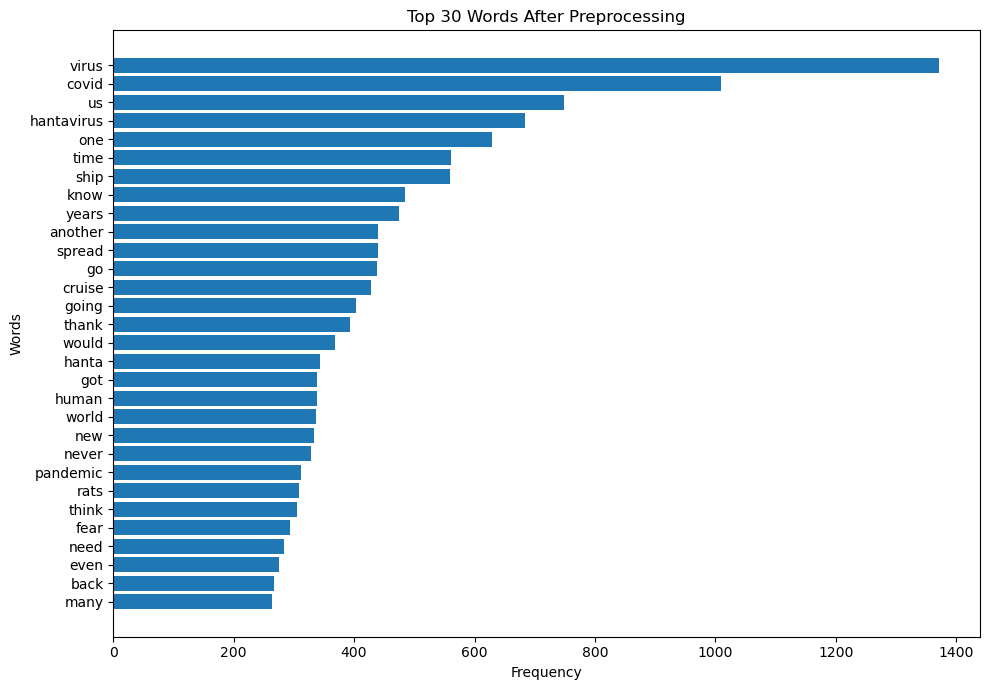

In [49]:
# show top words after preprocessing
top_processed_words = commentTermFreqCounter.most_common(30)

terms = [word for word, count in top_processed_words]
values = [count for word, count in top_processed_words]

plt.figure(figsize=(10, 7))
plt.barh(terms, values)
plt.gca().invert_yaxis()

plt.title("Top 30 Words After Preprocessing")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

In [50]:
# save cleaned english comments for later sentiment analysis
english_comments_df.to_csv("Data/youtube_comments_cleaned.csv", index=False)

print("Saved cleaned comments to Data/youtube_comments_cleaned.csv")

Saved cleaned comments to Data/youtube_comments_cleaned.csv
